# Tutorial 06 — Semantic Segmentation with Oxford-IIIT Pet

## Introduction

In this tutorial, you will build an **end-to-end semantic segmentation pipeline** using the Oxford-IIIT Pet dataset. Each image has a trimap annotation with three classes:

- **0 — pet**
- **1 — border**
- **2 — background**

You will first run a compact U-Net baseline, then complete key components, evaluate the model using **pixel accuracy**, **Dice score**, and **mean Intersection over Union (mIoU)**, analyse failure cases, and develop an improved model.

The baseline is intentionally modest. Correctly completing it earns the core marks; higher marks require a justified improvement and stronger validation performance.


## Submission

Submitted by **Nguyen Nhat Quang** · seed `42` · 128×128 · batch 16 · AdamW (lr 3e-4, wd 1e-4) · loss 0.5 CE + 0.5 Dice.
Baseline: SmallUNet, 5 epochs → **validation mIoU 0.616** (test 0.626). Final: ResNet-34 U-Net, 25 epochs, cosine LR → **validation mIoU 0.785** (test 0.792). Full comparison table in Section 5; trained on a Colab GPU.

Submit the following through Gradebook:

- `Tutorial06_Pet_Segmentation_Student.ipynb` with all TODO sections completed
- `best_pet_segmentation.pth` containing your best model state dictionary
- `predictions/` containing predicted masks for the provided evaluation images
- A short summary table comparing the baseline and your improved method

### Marking scheme (100 points)

| Section | Points |
|---|---:|
| Q1 — Dataset and paired transforms | 10 |
| Q2 — U-Net implementation | 20 |
| Q3 — Losses and segmentation metrics | 20 |
| Q4 — Training, evaluation, and failure analysis | 20 |
| Q5 — Improved method and reflection | 30 |

Do not remove the `###YOUR CODE HERE###` markers in the student notebook. Keep your notebook reproducible and state your random seed, hyperparameters, and validation score.

## 0. Setup

The notebook supports CPU, Apple Silicon (MPS), and CUDA. Training is substantially faster on a GPU. The first run downloads Oxford-IIIT Pet through `torchvision`.

**Google Colab:** Runtime → Change runtime type → **T4 GPU**, then Runtime → **Run all** (≈15–20 min).
The last cell downloads `best_pet_segmentation.pth`, `Nguyen_Nhat_Quang.xlsx` and `predictions.zip`; then File → Download → `.ipynb`.

In [1]:
# If needed:
# !pip install torch torchvision matplotlib tqdm pillow --quiet

import random
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import functional as TF
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("device:", device)

device: cuda


## 1. Dataset and paired transforms

The image and mask must receive the **same geometric transformation**. The original trimap uses labels 1, 2, and 3; we remap them to 0, 1, and 2 for `CrossEntropyLoss`.

The split supplied by torchvision is `trainval` or `test`. We create a reproducible training/validation split from `trainval`.


In [2]:
DATA_ROOT = "./data"
IMAGE_SIZE = 128
BATCH_SIZE = 16

raw_trainval = OxfordIIITPet(
    root=DATA_ROOT, split="trainval", target_types="segmentation", download=True
)
raw_test = OxfordIIITPet(
    root=DATA_ROOT, split="test", target_types="segmentation", download=True
)

class PetSegmentationDataset(Dataset):
    def __init__(self, base_dataset, image_size=128, augment=False):
        self.base = base_dataset
        self.image_size = image_size
        self.augment = augment

    def __len__(self):
        return len(self.base)

    def __getitem__(self, index):
        image, mask = self.base[index]
        image = TF.resize(image, [self.image_size, self.image_size],
                          interpolation=TF.InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.image_size, self.image_size],
                         interpolation=TF.InterpolationMode.NEAREST)

        if self.augment:
            # Paired geometric augmentation: apply the same random decision to both.
            if torch.rand(1).item() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # Q1.1: sample one angle and rotate image and raw trimap together.
            ###YOUR CODE HERE###
            angle = float(torch.empty(1).uniform_(-10, 10))
            image = TF.rotate(image, angle, interpolation=TF.InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST, fill=2)
            # Remember: Oxford raw labels are 1=pet, 2=background, 3=border; use mask fill=2.

        image = TF.to_tensor(image)
        image = TF.normalize(
            image,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )
        raw_mask = torch.as_tensor(np.array(mask), dtype=torch.long)
        # Map Oxford labels to the tutorial convention: 0=pet, 1=border, 2=background.
        mask = torch.empty_like(raw_mask)
        mask[raw_mask == 1] = 0
        mask[raw_mask == 3] = 1
        mask[raw_mask == 2] = 2
        return image, mask

NUM_WORKERS = 2 if device.type == "cuda" else 0  # parallel JPEG decoding on Colab; 0 is safest on macOS/Windows

generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(raw_trainval), generator=generator).tolist()
n_val = int(0.15 * len(indices))
val_indices, train_indices = indices[:n_val], indices[n_val:]

train_set = Subset(PetSegmentationDataset(raw_trainval, IMAGE_SIZE, augment=True), train_indices)
val_set = Subset(PetSegmentationDataset(raw_trainval, IMAGE_SIZE, augment=False), val_indices)
test_set = PetSegmentationDataset(raw_test, IMAGE_SIZE, augment=False)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"train={len(train_set)}, val={len(val_set)}, test={len(test_set)}")

100%|██████████| 792M/792M [00:39<00:00, 20.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.4MB/s]


train=3128, val=552, test=3669


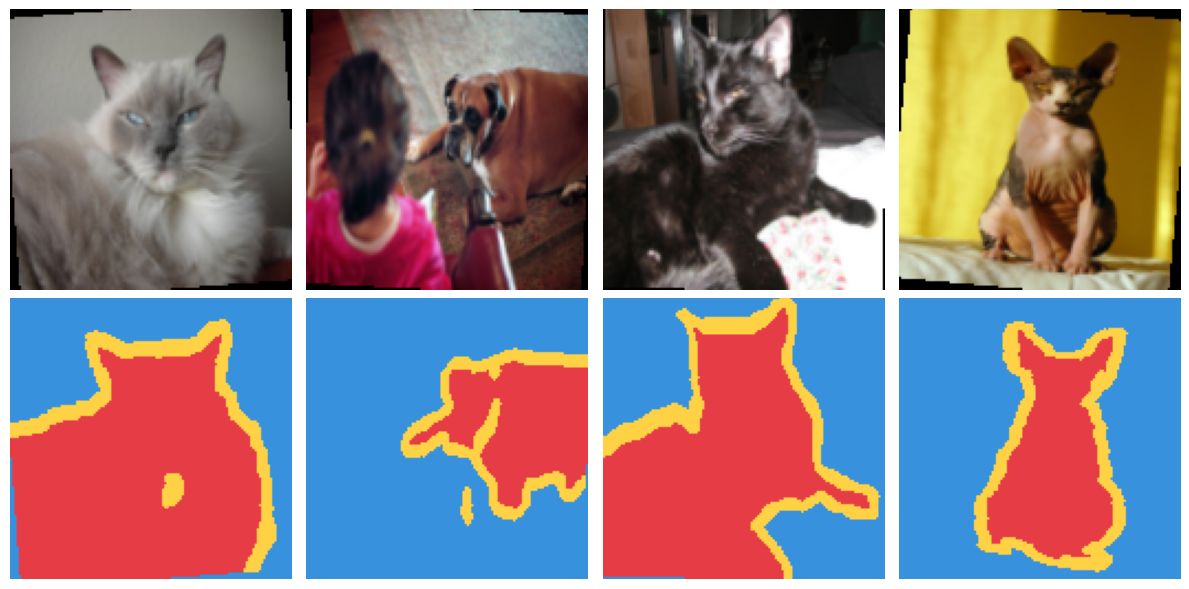

In [3]:
CLASS_NAMES = ["pet", "border", "background"]
CLASS_COLOURS = np.array([[230, 60, 70], [255, 210, 70], [55, 145, 220]], dtype=np.uint8)

def denormalize(image):
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    return (image.cpu() * std + mean).clamp(0, 1)

def colour_mask(mask):
    return CLASS_COLOURS[mask.cpu().numpy()]

images, masks = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(denormalize(images[i]).permute(1, 2, 0))
    axes[0, i].axis("off")
    axes[1, i].imshow(colour_mask(masks[i]))
    axes[1, i].axis("off")
plt.tight_layout()


### Q1.1 Paired augmentation (10 pts)

Add a random rotation in `[-10°, 10°]` to both the image and mask.

- Use bilinear interpolation for the RGB image.
- Use nearest-neighbour interpolation for the mask.
- Explain why nearest-neighbour interpolation is required for class labels.


In [4]:
# Written answer: Why must the segmentation mask use nearest-neighbour interpolation?
# ### YOUR ANSWER HERE ###
# Mask pixels are class IDs, not intensities. Bilinear interpolation averages neighbouring labels, producing values
# that are not a class or are the wrong class (e.g. averaging raw pet=1 and border=3 gives 2 = background).
# Nearest-neighbour copies an existing label, so every pixel keeps a valid class and boundaries are not smeared.
# (The same three lines are inlined in PetSegmentationDataset because the loader is used before this cell runs.)
def apply_paired_rotation(image, mask):
    angle = float(torch.empty(1).uniform_(-10, 10))
    image = TF.rotate(image, angle, interpolation=TF.InterpolationMode.BILINEAR)
    mask = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST, fill=2)  # fill = raw background
    return image, mask

## 2. Runnable baseline — compact U-Net

U-Net combines a contracting encoder with an expanding decoder and skip connections. The skip connections recover fine spatial details lost during downsampling.


In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class SmallUNet(nn.Module):
    def __init__(self, num_classes=3, base=32):
        super().__init__()
        self.enc1 = DoubleConv(3, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.bridge = DoubleConv(base * 2, base * 4)
        self.pool = nn.MaxPool2d(2)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.head = nn.Conv2d(base, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bridge(self.pool(e2))
        d2 = self.up2(b)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return self.head(d1)

baseline_model = SmallUNet().to(device)
x, y = next(iter(train_loader))
logits = baseline_model(x.to(device))
print("input:", x.shape, "logits:", logits.shape, "mask:", y.shape)


input: torch.Size([16, 3, 128, 128]) logits: torch.Size([16, 3, 128, 128]) mask: torch.Size([16, 128, 128])


### Q2.1 Complete an upsampling block (15 pts)

Implement `UpBlock`. It must upsample the decoder feature, concatenate the matching encoder feature along the channel dimension, and apply `DoubleConv`.


In [6]:
class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        ###YOUR CODE HERE###
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        ###YOUR CODE HERE###
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:  # guard against odd input sizes
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))

print(UpBlock(128, 64, 64)(torch.randn(2, 128, 32, 32), torch.randn(2, 64, 64, 64)).shape)  # (2, 64, 64, 64)

torch.Size([2, 64, 64, 64])


### Q2.2 Shape reasoning and skip connections (5 pts)

For input `(B, 3, 128, 128)`, give the shapes of `e1`, `e2`, `b`, `d2`, and the final logits. In 3–5 sentences, explain why skip connections are especially useful for segmentation boundaries.


**Your answer:**

| tensor | shape for input (B, 3, 128, 128) |
|---|---|
| `e1` | (B, 32, 128, 128) |
| `e2` | (B, 64, 64, 64) |
| `b` | (B, 128, 32, 32) |
| `d2` | (B, 64, 64, 64) — `up2` gives (B, 64, 64, 64), concat with `e2` gives (B, 128, 64, 64), `dec2` gives (B, 64, 64, 64) |
| logits | (B, 3, 128, 128) |

Each max-pool halves the resolution, so the bridge sees the image at 32×32: it knows *what* is present but only roughly *where*, and upsampling alone cannot restore the lost high-frequency detail, so boundaries come out blurry. Skip connections concatenate the high-resolution encoder features (edges, fur texture, exact positions) at the matching scale, so the decoder combines coarse semantics with precise location and can put the boundary on the right pixel. This matters most for the border class, a band only a few pixels wide that would almost vanish at 32×32. Skips also shorten the gradient path to early layers, which makes training easier.

## 3. Losses and segmentation metrics

Cross-entropy supervises every pixel. Dice and IoU measure overlap and are more informative when classes occupy very different numbers of pixels.


In [7]:
def soft_dice_loss(logits, targets, num_classes=3, eps=1e-6):
    probs = logits.softmax(dim=1)
    one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    intersection = (probs * one_hot).sum(dims)
    denominator = probs.sum(dims) + one_hot.sum(dims)
    dice = (2 * intersection + eps) / (denominator + eps)
    return 1 - dice.mean()

def combined_loss(logits, targets, dice_weight=0.5):
    ce = F.cross_entropy(logits, targets)
    dice = soft_dice_loss(logits, targets)
    return (1 - dice_weight) * ce + dice_weight * dice


### Q3.1 Confusion matrix and metrics (15 pts)

Complete the confusion-matrix update and calculate:

- pixel accuracy,
- IoU for each class,
- mean IoU,
- Dice score for each class.

Rows represent ground truth and columns represent predictions.


In [8]:
@torch.no_grad()
def update_confusion(confusion, logits, targets, num_classes=3):
    ###YOUR CODE HERE###
    idx = (targets.flatten() * num_classes + logits.argmax(1).flatten()).cpu()  # row = truth, col = prediction
    return confusion + torch.bincount(idx, minlength=num_classes ** 2).reshape(num_classes, num_classes)

def metrics_from_confusion(confusion, eps=1e-6):
    ###YOUR CODE HERE###
    cm = confusion.double()
    tp, gt, pred = cm.diag(), cm.sum(1), cm.sum(0)
    iou = tp / (gt + pred - tp + eps)
    dice = 2 * tp / (gt + pred + eps)
    out = {"pixel_acc": (tp.sum() / (cm.sum() + eps)).item(), "miou": iou.mean().item(), "mdice": dice.mean().item()}
    out.update({f"iou_{c}": v for c, v in zip(CLASS_NAMES, iou.tolist())})
    out.update({f"dice_{c}": v for c, v in zip(CLASS_NAMES, dice.tolist())})
    return out

# Sanity check: a perfect prediction gives 1.0 everywhere.
_t = torch.randint(0, 3, (2, 8, 8))
print(metrics_from_confusion(update_confusion(torch.zeros(3, 3, dtype=torch.long), F.one_hot(_t, 3).permute(0, 3, 1, 2).float(), _t)))

{'pixel_acc': 0.9999999921875001, 'miou': 0.9999999763372074, 'mdice': 0.9999999881686036, 'iou_pet': 0.9999999782608701, 'iou_border': 0.9999999777777784, 'iou_background': 0.9999999729729737, 'dice_pet': 0.999999989130435, 'dice_border': 0.9999999888888891, 'dice_background': 0.9999999864864867}


### Q3.2 Loss comparison (5 pts)

Explain one advantage and one limitation of:

1. pixel-wise cross-entropy;
2. Dice loss;
3. the combined loss used above.

Which loss would you choose if the thin border class performs poorly?


**Your answer:**

| Loss | Advantage | Limitation |
|---|---|---|
| Pixel-wise cross-entropy | Dense, smooth, stable gradients for every pixel; calibrated probabilities; easy to optimise. | Every pixel counts equally, so the large pet/background regions dominate and the thin border is under-weighted; it does not directly optimise overlap (IoU/Dice). |
| Dice loss | Directly optimises overlap and is normalised per class, so a small class counts as much as a large one (robust to imbalance). | Noisy, unstable gradients when a class is small or absent in a batch; poorly calibrated, over-confident outputs; slow to converge on its own. |
| Combined (CE + Dice) | CE gives stable per-pixel learning, Dice aligns training with the evaluation metric and counteracts imbalance. | Extra hyperparameter (`dice_weight`) to tune; still no explicit boundary term, so thin structures can stay blurry. |

**If the border class performs poorly**, I would keep the combined loss but use a class-weighted cross-entropy (up-weighting border, e.g. by inverse frequency) and/or a larger `dice_weight`: Dice is normalised per class, so the thin border counts as much as the large classes, while CE keeps optimisation stable. A boundary-aware or focal term would be the next step.

## 4. Train and evaluate the baseline


In [9]:
def train_one_epoch(model, loader, optimizer, device, loss_fn=combined_loss):
    model.train()
    total_loss = 0.0
    for images, masks in tqdm(loader, leave=False):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = loss_fn(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, device, num_classes=3, loss_fn=combined_loss):
    model.eval()
    confusion = torch.zeros(num_classes, num_classes, dtype=torch.long)
    total_loss = 0.0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        total_loss += loss_fn(logits, masks).item() * images.size(0)
        confusion = update_confusion(confusion, logits, masks, num_classes)
    metrics = metrics_from_confusion(confusion)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics

EPOCHS = 5
model = SmallUNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

best_miou = -1.0
t0 = time.time()
history = []
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_metrics = evaluate(model, val_loader, device)
    history.append((train_loss, val_metrics["loss"], val_metrics["miou"]))
    print(f"epoch {epoch+1:02d} | train {train_loss:.4f} | val {val_metrics['loss']:.4f} | mIoU {val_metrics['miou']:.4f}")
    if val_metrics["miou"] > best_miou:
        best_miou = val_metrics["miou"]
        torch.save(model.state_dict(), "baseline_pet_segmentation.pth")

baseline_time = time.time() - t0

# Use the best validation checkpoint for every later baseline result and figure.
model.load_state_dict(torch.load("baseline_pet_segmentation.pth", map_location=device))
baseline_metrics = evaluate(model, val_loader, device)
print("best baseline validation:", baseline_metrics)

  0%|          | 0/196 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c20c9e4a340>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c20c9e4a340>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

    self._shutdown_workers()  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

epoch 01 | train 0.6256 | val 0.5313 | mIoU 0.5152


  0%|          | 0/196 [00:00<?, ?it/s]

epoch 02 | train 0.4830 | val 0.4459 | mIoU 0.5670


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c20c9e4a340>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'Exception ignored in: 
AssertionError<function _MultiProcessingDataLoaderIter.__del__ at 0x7c20c9e4a340>
: can only test a child process
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c20c9e4a340>    
self._shutdown_workers()  File "/usr/local/lib/python3.13/dist-packages/torch/utils/da

epoch 04 | train 0.4122 | val 0.3985 | mIoU 0.6031


  0%|          | 0/196 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c20c9e4a340>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c20c9e4a340>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

epoch 05 | train 0.3901 | val 0.3811 | mIoU 0.6159
best baseline validation: {'pixel_acc': 0.828114938044802, 'miou': 0.6159172722086846, 'mdice': 0.7461311886629897, 'iou_pet': 0.6637452881368514, 'iou_border': 0.37640474022601733, 'iou_background': 0.8076017882631853, 'dice_pet': 0.7978929141012299, 'dice_border': 0.5469390350460556, 'dice_background': 0.8935616168416837, 'loss': 0.3810752336529718}


### Q4.1 Visualise predictions (15 pts)

Display at least four validation examples with three columns: input image, ground-truth mask, and predicted mask. Include at least one difficult example.


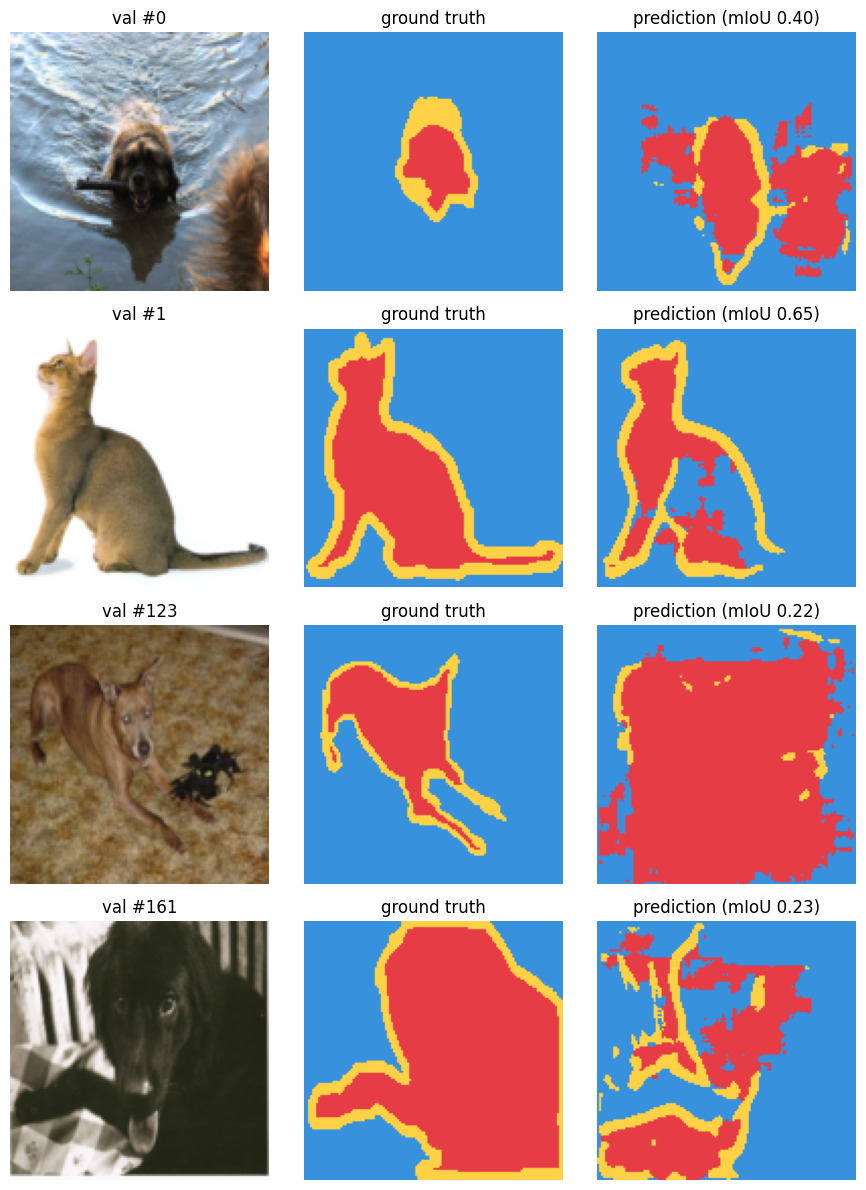

In [10]:
@torch.no_grad()
def per_image_metrics(model, loader, device):
    model.eval()
    out = []
    for images, masks in loader:
        logits = model(images.to(device)).cpu()
        for lg, m in zip(logits, masks):
            out.append(metrics_from_confusion(update_confusion(torch.zeros(3, 3, dtype=torch.long), lg[None], m[None])))
    return out

@torch.no_grad()
def show_predictions(model, loader, device, n=4):
    ###YOUR CODE HERE###
    scores = np.array([m["miou"] for m in per_image_metrics(model, loader, device)])
    picks = list(range(n - 2)) + np.argsort(scores)[:2].tolist()  # n-2 typical examples + the 2 hardest
    fig, axes = plt.subplots(len(picks), 3, figsize=(9, 3 * len(picks)))
    for row, i in zip(axes, picks):
        image, mask = loader.dataset[i]
        pred = model(image[None].to(device)).argmax(1)[0]
        panels = [denormalize(image).permute(1, 2, 0), colour_mask(mask), colour_mask(pred)]
        titles = [f"val #{i}", "ground truth", f"prediction (mIoU {scores[i]:.2f})"]
        for ax, panel, title in zip(row, panels, titles):
            ax.imshow(panel); ax.set_title(title); ax.axis("off")
    plt.tight_layout(); plt.show()

show_predictions(model, val_loader, device)

### Q4.2 Failure analysis (5 pts)

Choose two failure cases. For each, identify where the model fails and propose a plausible cause, such as fine fur boundaries, occlusion, similar foreground/background colour, small objects, or resizing.


**Your answer:** the two hardest validation images (lowest per-image mIoU) are the last two rows of the figure above: val #123 and val #161.

**Failure 1: val #123 (mIoU 0.22), look-alike textured background.** A tan dog lies on a shaggy beige-and-brown carpet. The baseline labels almost the whole carpet as pet (a large red rectangle), so the pet class leaks into the background and the dog's real outline and border are lost. *Plausible cause:* the carpet has nearly the same colour and fur-like texture as the dog. With only two poolings, each baseline output pixel sees about 45×45 px of the 128×128 input, so the model classifies from local colour and texture and cannot use the dog's overall shape to reject the carpet.

**Failure 2: val #161 (mIoU 0.23), dark, low-contrast pet on a cluttered background.** A black dog fills most of a dark, almost monochrome photo, with a checked blanket and white railings behind it. Most of the dog's body is predicted as background, and false border lines follow the high-contrast edges of the railings and blanket instead of the dog's outline. *Plausible cause:* the black fur has little texture or contrast, so the strongest edges in the image belong to the background, and the small receptive field treats those edges as object boundaries. Shadows and the loss of detail when resizing to 128×128 weaken the true outline further.

Both failures come from missing global context, which motivates the deeper, pretrained encoder in Section 5.

## 5. Improved model — performance challenge (30 pts)

The supplied Small U-Net is only a baseline. Develop **one clearly motivated improvement** and compare it fairly against the baseline using the same train/validation split.

Possible directions:

- stronger augmentation (paired crop, scale, rotation, colour jitter);
- higher input resolution;
- deeper/wider U-Net, residual blocks, or attention gates;
- a pretrained encoder;
- class-weighted, focal, boundary-aware, or improved Dice loss;
- learning-rate scheduling, longer training, early stopping, or test-time augmentation.

### Requirements

1. State one hypothesis before training.
2. Change one main factor at a time for the primary ablation.
3. Save your best validation checkpoint as `best_pet_segmentation.pth`.
4. Report baseline and improved validation metrics in one table.
5. Briefly discuss accuracy, computational cost, and remaining failure cases.

Higher scores are awarded for a sound method, reproducible comparison, clear analysis, and improved **validation mIoU**—not complexity alone.


In [11]:
# Hypothesis: the baseline learns every feature from scratch on ~3.1k images and, with only two poolings, sees only
#   ~45 px of a 128 px image, so it confuses fur with look-alike background and blurs the border. An ImageNet-pretrained
#   ResNet-34 encoder (stride 32, image-wide receptive field, generic edge/texture/part features) should raise
#   validation mIoU with the same resolution, loss, optimiser, epochs and split, with the largest relative gain on border.
# Main change: encoder = pretrained ResNet-34, decoder = the Q2.1 UpBlock. Everything else is identical (primary ablation).
#   Second, separate step for the final model: train the same network longer (25 epochs) with a cosine LR schedule.
# Training code:
###YOUR CODE HERE###
from torchvision.models import resnet34, ResNet34_Weights

class ResUNet(nn.Module):
    """U-Net with an ImageNet-pretrained ResNet-34 encoder and the Q2.1 UpBlock decoder."""
    def __init__(self, num_classes=3, pretrained=True):
        super().__init__()
        r = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1 if pretrained else None)
        self.full = DoubleConv(3, 32)                  # 32 @ H: full-resolution detail for the border
        self.encoder = nn.ModuleList([
            nn.Sequential(r.conv1, r.bn1, r.relu),     # 64 @ H/2
            nn.Sequential(r.maxpool, r.layer1),        # 64 @ H/4
            r.layer2, r.layer3, r.layer4,              # 128 @ H/8, 256 @ H/16, 512 @ H/32
        ])
        self.decoder = nn.ModuleList([UpBlock(512, 256, 256), UpBlock(256, 128, 128), UpBlock(128, 64, 64),
                                      UpBlock(64, 64, 64), UpBlock(64, 32, 32)])
        self.head = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        skips = [self.full(x)]
        for stage in self.encoder:
            x = stage(x)
            skips.append(x)
        x = skips.pop()
        for up in self.decoder:
            x = up(x, skips.pop())
        return self.head(x)

def fit(model, epochs, ckpt, cosine=False):
    """Baseline recipe (AdamW 3e-4, combined loss, same loaders); keeps the best-validation-mIoU checkpoint."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs) if cosine else None
    best, t0 = -1.0, time.time()
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        val = evaluate(model, val_loader, device)
        if scheduler:
            scheduler.step()
        print(f"epoch {epoch+1:02d} | train {train_loss:.4f} | val {val['loss']:.4f} | mIoU {val['miou']:.4f}")
        if val["miou"] > best:
            best = val["miou"]
            torch.save(model.state_dict(), ckpt)
    train_min = (time.time() - t0) / 60
    model.load_state_dict(torch.load(ckpt, map_location=device))
    return {**evaluate(model, val_loader, device), "train_min": train_min}

# Primary ablation: only the encoder changes.
torch.manual_seed(SEED)
resunet_5ep = fit(ResUNet().to(device), EPOCHS, "resunet_5ep.pth")

# Final model: same network, longer cosine schedule -> best_pet_segmentation.pth
FINAL_EPOCHS = 25
torch.manual_seed(SEED)
improved = ResUNet().to(device)
improved_metrics = fit(improved, FINAL_EPOCHS, "best_pet_segmentation.pth", cosine=True)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 130MB/s]


  0%|          | 0/196 [00:00<?, ?it/s]

epoch 01 | train 0.4684 | val 0.4106 | mIoU 0.6465


  0%|          | 0/196 [00:00<?, ?it/s]

...

  0%|          | 0/196 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c20c9e4a340>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c20c9e4a340>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

epoch 24 | train 0.1297 | val 0.1853 | mIoU 0.7846


  0%|          | 0/196 [00:00<?, ?it/s]

epoch 25 | train 0.1293 | val 0.1853 | mIoU 0.7853


,pixel_acc,iou_pet,iou_border,iou_background,miou,mdice,params_M,train_min
Baseline SmallUNet (5 ep),0.8281,0.6637,0.3764,0.8076,0.6159,0.7461,0.4672,2.0039
ResUNet-34 (5 ep): encoder only,0.9059,0.8346,0.4980,0.9057,0.7461,0.8418,24.4711,2.4875
"ResUNet-34 (25 ep, cosine): final",0.9260,0.8709,0.5532,0.9320,0.7853,0.8694,24.4711,13.0208
Δ final − baseline,0.0979,0.2071,0.1768,0.1244,0.1694,0.1232,24.0038,11.0169


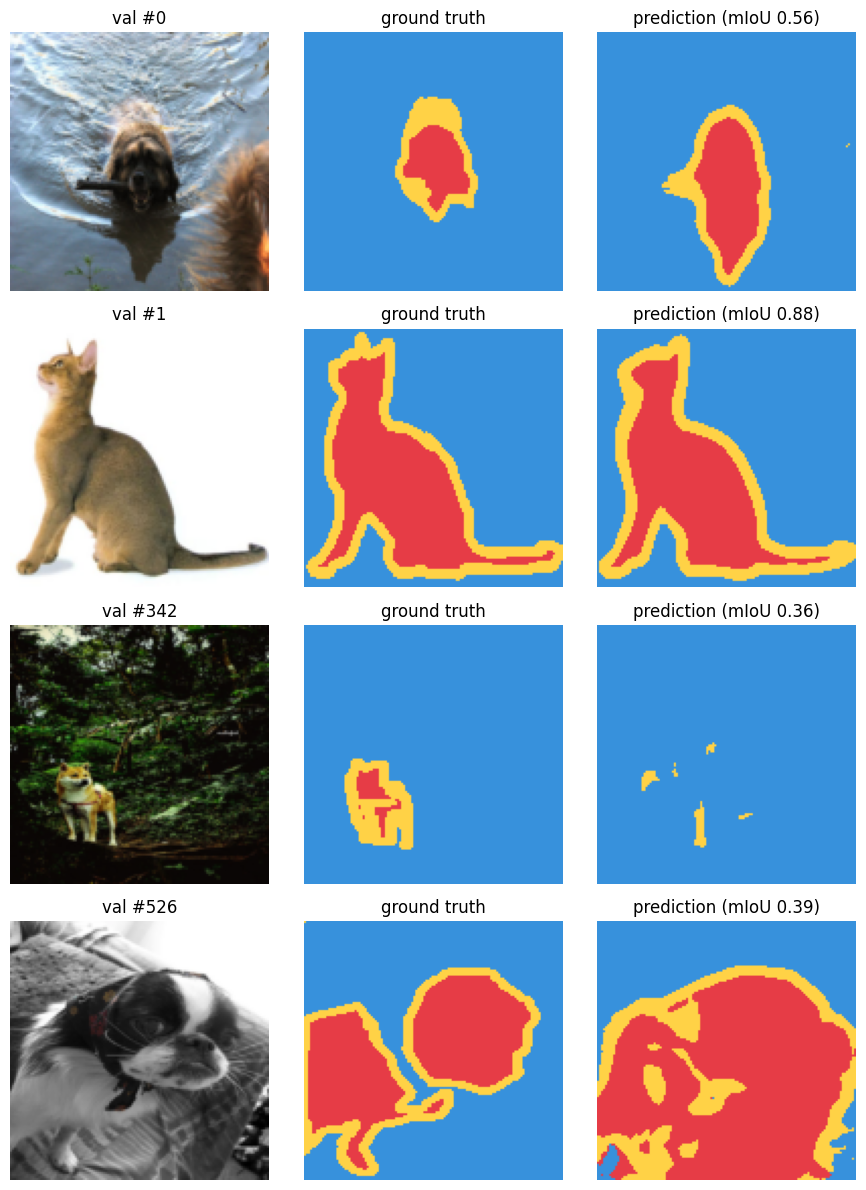

In [12]:
# Baseline vs improved on the same validation split
n_params = lambda m: sum(p.numel() for p in m.parameters()) / 1e6
cols = ["pixel_acc", "iou_pet", "iou_border", "iou_background", "miou", "mdice", "params_M", "train_min"]
val_table = pd.DataFrame({
    f"Baseline SmallUNet ({EPOCHS} ep)": {**baseline_metrics, "params_M": n_params(model), "train_min": baseline_time / 60},
    f"ResUNet-34 ({EPOCHS} ep): encoder only": {**resunet_5ep, "params_M": n_params(improved)},
    f"ResUNet-34 ({FINAL_EPOCHS} ep, cosine): final": {**improved_metrics, "params_M": n_params(improved)},
}).T[cols]
val_table.loc["Δ final − baseline"] = val_table.iloc[2] - val_table.iloc[0]
display(val_table.round(4))

show_predictions(improved, val_loader, device)  # remaining failure cases of the final model

### Final reflection

In 150–250 words, answer:

- What improved, and which class benefited most?
- Was the gain large enough to justify the additional computation?
- What would you try next with more time or compute?
- What limitation might appear on images outside Oxford-IIIT Pet?


**Your answer:**

**What improved.** On the same validation split, mIoU rose from 0.616 (baseline) to 0.746 when only the encoder was replaced by a pretrained ResNet-34 (same 5 epochs), and to 0.785 after 25 epochs with a cosine schedule. Test mIoU rose from 0.626 to 0.792. Every class improved. Pet gained most in absolute IoU (0.664 → 0.871), while the thin border gained most in relative terms (0.376 → 0.553, +47%) but is still the weakest class.

**Was it worth it?** Parameters grew from 0.47 M to 24.5 M, yet the 5-epoch run took 2.5 min instead of 2.0 min: +0.130 mIoU for about 25% more time, clearly worthwhile. The longer schedule added +0.039 for five times the training time (13 min), a smaller but still cheap gain. Because the new encoder is both pretrained and deeper, this experiment cannot separate those two effects; a `pretrained=False` run would.

**Next steps.** Train at 256×256 so the border survives resizing, add a class-weighted or boundary-aware loss, use scale, crop and colour augmentation, and try flip test-time augmentation.

**Limitations.** The final model still almost completely misses a small dog in a forest (val #342, mIoU 0.36), and the val #526 mask (0.39) looks inconsistent with the photo, so part of that error may be label noise. Other animals, several pets, or unusual cameras and lighting would likely reduce accuracy further.

## 6. Export predictions

Use the best validation checkpoint and export integer masks. Do not apply colour mapping to the files used for evaluation.


In [13]:
@torch.no_grad()
def export_predictions(model, loader, output_dir="predictions"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    model.eval()
    sample_id = 0
    for images, _ in loader:
        preds = model(images.to(device)).argmax(1).cpu().numpy().astype(np.uint8)
        for pred in preds:
            Image.fromarray(pred).save(output_dir / f"{sample_id:05d}.png")
            sample_id += 1
    print(f"saved {sample_id} masks to {output_dir}")

# Load your best checkpoint before exporting:
model = ResUNet(pretrained=False).to(device)
model.load_state_dict(torch.load("best_pet_segmentation.pth", map_location=device))
export_predictions(model, test_loader)

saved 3669 masks to predictions


## 7. Final test results → `Your_Name.xlsx`

Sheets: `test_summary` (baseline vs improved on the test split), `val_comparison` (Section 5 table), `test_per_image` (per-image metrics of the improved model, matched to the files in `predictions/`).

In [14]:
STUDENT_NAME = "Nguyen_Nhat_Quang"

baseline = SmallUNet().to(device)
baseline.load_state_dict(torch.load("baseline_pet_segmentation.pth", map_location=device))
test_table = pd.DataFrame({
    "Baseline SmallUNet": evaluate(baseline, test_loader, device),
    "Improved ResUNet-34 (best_pet_segmentation.pth)": evaluate(model, test_loader, device),
}).T
per_image = pd.DataFrame(per_image_metrics(model, test_loader, device))
per_image.insert(0, "image", [Path(p).stem for p in raw_test._images])
per_image.insert(1, "pred_file", [f"{i:05d}.png" for i in range(len(per_image))])

with pd.ExcelWriter(f"{STUDENT_NAME}.xlsx") as writer:
    test_table.to_excel(writer, sheet_name="test_summary")
    val_table.to_excel(writer, sheet_name="val_comparison")
    per_image.to_excel(writer, sheet_name="test_per_image", index=False)
display(test_table.round(4))

import shutil
shutil.make_archive("predictions", "zip", "predictions")
try:
    from google.colab import files
    for f in ["best_pet_segmentation.pth", f"{STUDENT_NAME}.xlsx", "predictions.zip"]:
        files.download(f)
except ImportError:
    print("saved to", Path.cwd())

,pixel_acc,miou,mdice,iou_pet,iou_border,iou_background,dice_pet,dice_border,dice_background,loss
Baseline SmallUNet,0.8307,0.6260,0.7557,0.6702,0.3991,0.8087,0.8025,0.5705,0.8942,0.3742
Improved ResUNet-34 (best_pet_segmentation.pth),0.9260,0.7918,0.8750,0.8679,0.5764,0.9312,0.9293,0.7313,0.9644,0.1871


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>